# 02 — Exploring the data (how every cleaning decision was found)
Run from the `notebooks/` directory. Pattern: **question → look → reading → decision**. Each plot is followed by a plain-English reading so the evidence is clear to anyone.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
tr = pd.read_csv('../data/train_test.csv', parse_dates=['date'])
va = pd.read_csv('../data/validation.csv', parse_dates=['date'])
print('train', tr.shape, '|', tr['date'].min().date(), '->', tr['date'].max().date())
print('val  ', va.shape, '|', va['date'].min().date(), '->', va['date'].max().date())
print('\nmissing per column (train):')
print(tr.isna().sum()[tr.isna().sum() > 0].to_string())

train (48000, 14) | 2025-01-01 -> 2025-10-31
val   (12000, 13) | 2025-11-01 -> 2025-12-31

missing per column (train):
weight          300
market_index    374


**Reading:** only `weight` (300) and `market_index` (374) have gaps in training — small enough to impute, large enough to flag.

## Q1: are negative weights real? Is there a ceiling?
Trucks cannot carry negative pounds, and the maximum (47,500) is suspiciously round.

In [2]:
w = tr['weight']
print('negatives:', (w < 0).sum(), '| NaN:', w.isna().sum())
print('min / max:', w.min(), '/', w.max())
print('\nmost common exact values:')
print(w.value_counts().head(6).to_string())

negatives: 292 | NaN: 300
min / max: -47500.0 / 47500.0

most common exact values:
weight
 47500.0    1191
 5000.0       31
-47500.0      13
 32436.0      10
 32153.0      10
 28444.0       9


**Reading:** one exact value (47,500) repeats ~1,200x while neighbours repeat ~10x. In smooth real-world data that is impossible — it is a recording ceiling. Negatives mirror it: sign-entry errors.

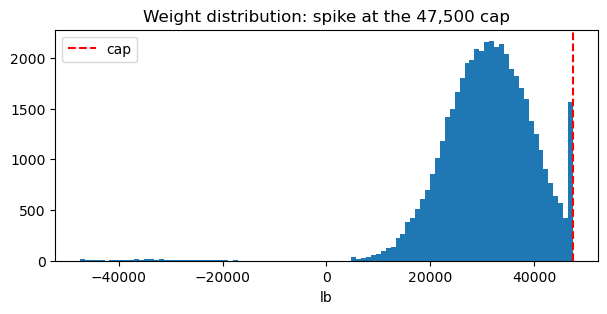

In [3]:
plt.figure(figsize=(7, 3))
plt.hist(w.dropna(), bins=100); plt.axvline(47500, color='r', ls='--', label='cap')
plt.title('Weight distribution: spike at the 47,500 cap'); plt.xlabel('lb'); plt.legend(); plt.show()

**Reading:** the red dashed line marks a lonely skyscraper at the far right — the cap. Everything left of it looks like a normal bell.
**Decision:** `abs()` + median impute + `weight_missing / weight_was_negative / weight_capped` flags (`cleaning.py`).

## Q2: does distance have a floor?

In [4]:
d = tr['distance']
print('minimum:', d.min(), '| rows at exactly 70.0:', (d == 70.0).sum())
print(d.value_counts().head(4).to_string())

minimum: 70.0 | rows at exactly 70.0: 48
distance
70.0     48
446.3    12
741.1    11
758.9    11


**Reading:** the smallest value is exactly 70.0 and it is also the most common value (48x vs ~10x). Same pile-up signature as the weight cap — a system floor.

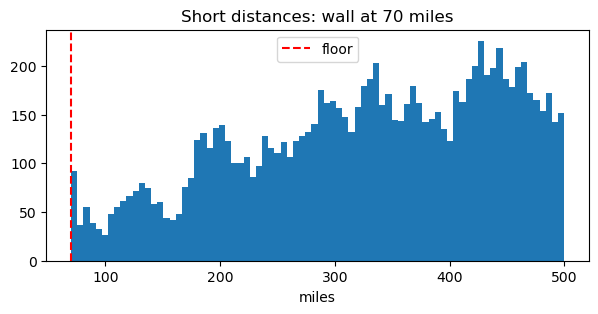

In [5]:
plt.figure(figsize=(7, 3)); plt.hist(d[d < 500], bins=80); plt.axvline(70, color='r', ls='--', label='floor')
plt.title('Short distances: wall at 70 miles'); plt.xlabel('miles'); plt.legend(); plt.show()

**Decision:** `dist_floor` flag (`cleaning.py`). Rows are kept — a 70-mile load is still a load.

## Q3: is the target well-behaved?

In [6]:
y = tr['posted_rate']
print(y.describe([.5, .95, .99]).round(1).to_string())

count    48000.0
mean      2374.0
std       1486.5
min         57.2
50%       2030.8
95%       4953.8
99%       5972.8
max      25533.0


**Reading:** median ~$2,031 but max ~$25,533 — ten times higher. The 99th percentile (~$5,973) vs the max already smells like corruption, not business.

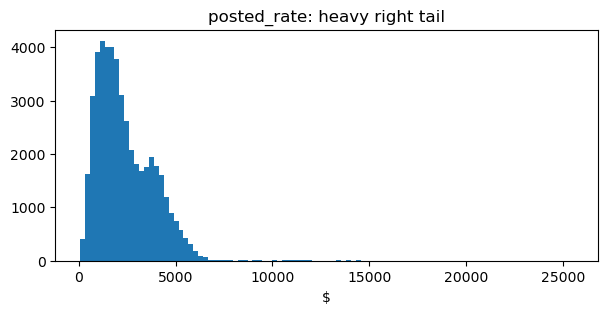

In [7]:
plt.figure(figsize=(7, 3)); plt.hist(y, bins=100)
plt.title('posted_rate: heavy right tail'); plt.xlabel('$'); plt.show()

**Reading:** most loads pile left, a thin tail stretches far right. Models trained on raw dollars chase that tail.

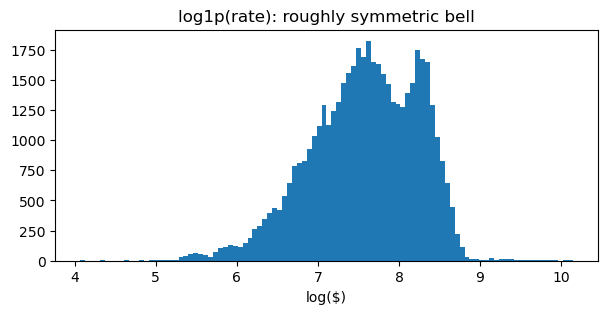

In [8]:
plt.figure(figsize=(7, 3)); plt.hist(np.log1p(y), bins=100)
plt.title('log1p(rate): roughly symmetric bell'); plt.xlabel('log($)'); plt.show()

**Reading:** after the log, the same data forms a bell curve — the shape models learn best. This one picture justifies `log1p` in `model.py`.

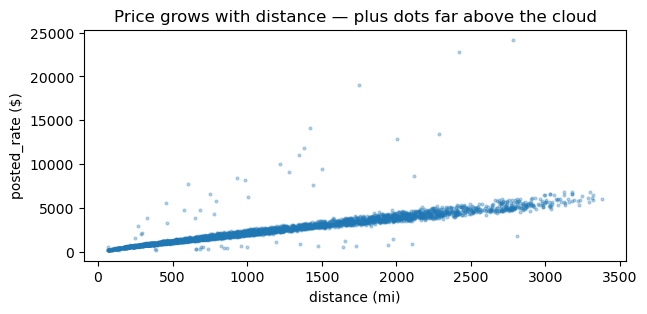

In [9]:
s = tr.sample(4000, random_state=0)
plt.figure(figsize=(7, 3)); plt.scatter(s['distance'], s['posted_rate'], s=4, alpha=0.3)
plt.xlabel('distance (mi)'); plt.ylabel('posted_rate ($)')
plt.title('Price grows with distance — plus dots far above the cloud'); plt.show()

**Reading:** a clear upward cloud (distance drives price) with stray dots floating far above it — the corrupted labels notebook 03 dissects.
**Decision:** model `log1p(rate)` with L1 loss; never delete rows (`model.py`).

## Q4: market_index — signal or trap?

In [10]:
print('market NaN train / val:', tr['market_index'].isna().sum(), va['market_index'].isna().sum())
print('market mean train / val: %.3f / %.3f' % (tr['market_index'].mean(), va['market_index'].mean()))

market NaN train / val: 374 249
market mean train / val: 1.083 / 0.927


**Reading:** the regime moved (1.08 vs 0.93) between train and test — the model will meet a market it never trained on.

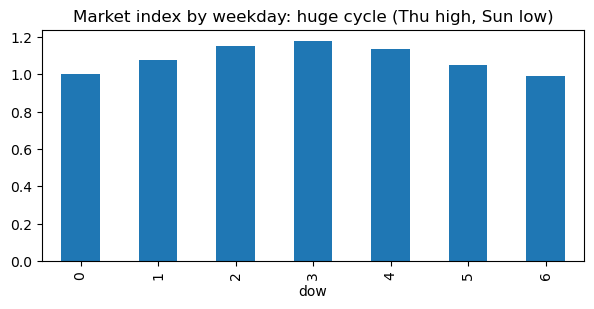

In [11]:
tr['dow'] = tr['date'].dt.dayofweek; tr['rpm'] = tr['posted_rate'] / tr['distance']
g = tr.groupby('dow').agg(mi=('market_index', 'mean'), rpm=('rpm', 'mean'))
g['mi'].plot.bar(figsize=(7, 3), title='Market index by weekday: huge cycle (Thu high, Sun low)'); plt.show()

**Reading:** the index swings ~20% across the week. Now compare with what prices actually do:

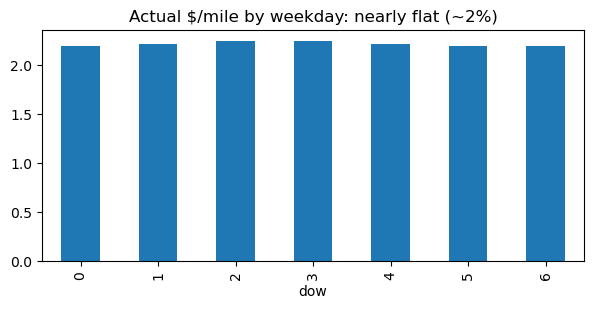

In [12]:
g['rpm'].plot.bar(figsize=(7, 3), title='Actual $/mile by weekday: nearly flat (~2%)'); plt.show()

**Reading:** prices barely move. A 20% signal driving 2% of outcome is mostly noise to a tree — feeding it raw invites overfitting.
**Decision:** daily-median smoothing (`mi_smooth`), keep raw too, add missing flag (`features.py`).

## Q5: what does quote_signal actually do?

In [13]:
print('corr quote-rate: %.3f' % tr['quote_signal'].corr(tr['posted_rate']))

corr quote-rate: -0.040


**Reading:** near zero — a linear model would discard this column as useless. But correlation only detects straight lines:

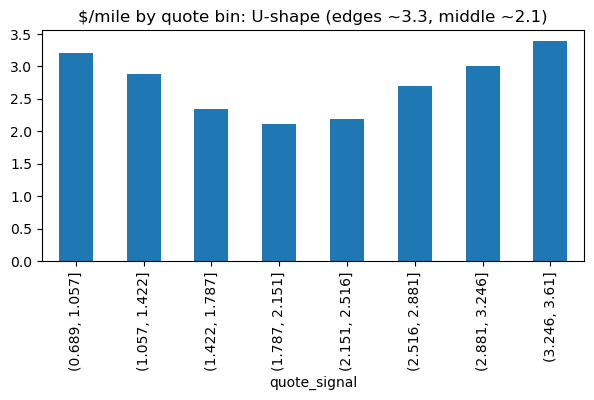

In [14]:
qb = tr.groupby(pd.cut(tr['quote_signal'], 8), observed=True)['rpm'].mean()
qb.plot.bar(figsize=(7, 3), title='$/mile by quote bin: U-shape (edges ~3.3, middle ~2.1)'); plt.show()

**Reading:** both extremes are expensive, the middle is cheap — a perfect U that trees split beautifully and linear models cannot see at all.
**Decision:** `qs_dev = |quote - median|` so one split captures both expensive edges (`features.py`).

## Q6: will city names survive validation?

In [15]:
tr_c = set(tr['pickup']) | set(tr['delivery']); va_c = set(va['pickup']) | set(va['delivery'])
new = sorted(va_c - tr_c)
print(len(new), 'unseen cities:', new)
print('rows touching a new city: %.1f%%' % ((va['pickup'].isin(new) | va['delivery'].isin(new)).mean() * 100))

8 unseen cities: ['Allentown', 'Charlotte', 'Chicago', 'Jackson', 'Knoxville', 'Laredo', 'Norfolk', 'San Diego']
rows touching a new city: 12.1%


**Reading:** 8 cities appear only in validation. Any city-ID encoding meets unknown categories on ~12% of test rows.
**Decision:** coordinates only, no city IDs (`features.py`). Both December cities exist in train, so the chart is safe.